Classification Accuracy: 0.4444444444444444


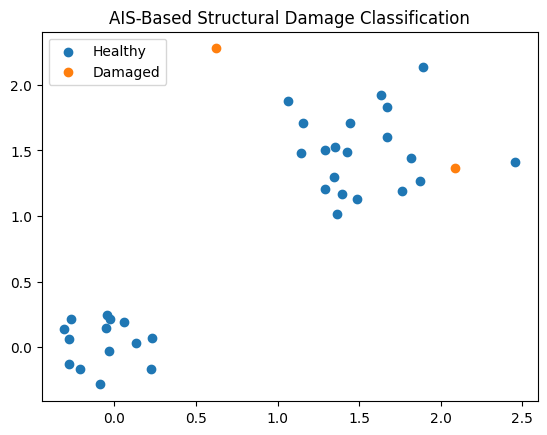

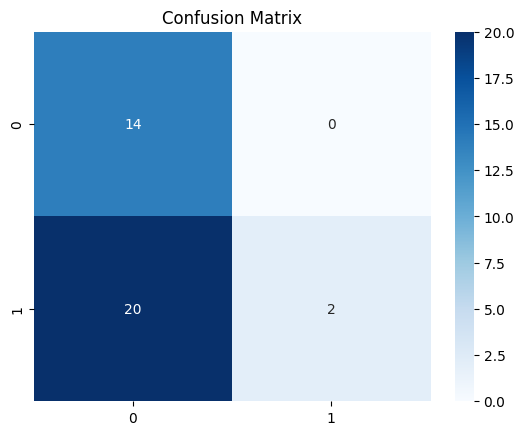

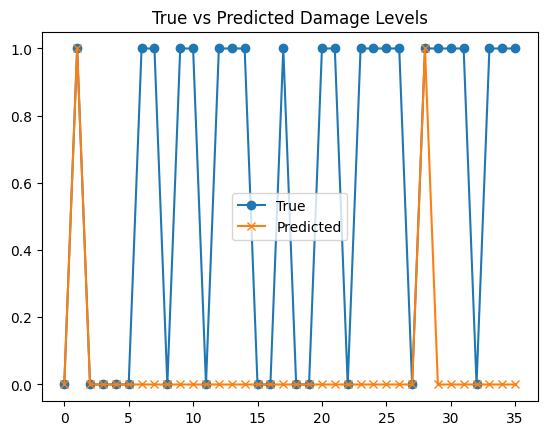

In [1]:
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Data
np.random.seed(1)
X = np.vstack((np.random.normal(0,0.25,(60,3)),
               np.random.normal(1.6,0.35,(60,3))))
y = np.array([0]*60 + [1]*60)

Xtr,Xte,Ytr,Yte = train_test_split(X,y,test_size=0.3)

# Detector
D=[]
while len(D)<25:
    x=np.random.uniform(-2,3,3)
    if np.min(np.linalg.norm(Xtr[Ytr==0]-x,axis=1))>0.9:
        D.append(x)
D=np.array(D)

# Prediction
yp = np.array([
    1 if np.min(np.linalg.norm(D-i,axis=1))<0.9 else 0
    for i in Xte
])

# Accuracy
print("Classification Accuracy:", accuracy_score(Yte,yp))

# Scatter
plt.scatter(Xte[yp==0,0],Xte[yp==0,1],label='Healthy')
plt.scatter(Xte[yp==1,0],Xte[yp==1,1],label='Damaged')
plt.legend(); plt.title("AIS-Based Structural Damage Classification")
plt.show()

# Confusion Matrix
sns.heatmap(confusion_matrix(Yte,yp),annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix"); plt.show()

# True vs Pred
plt.plot(Yte,label='True',marker='o')
plt.plot(yp,label='Predicted',marker='x')
plt.legend(); plt.title("True vs Predicted Damage Levels")
plt.show()